# `own_night` 라벨링 상태 확인 + 수동 라벨링

대상: `data/own_night/images`(45장). `own_night_0001`~`0027`은 `test_real_data`+`test_real_data2`
결합분으로 라벨이 있고(그중 7장은 의도된 negative — 박스 없음이 정상), `own_night_0028`~`0045`
18장은 라벨이 아예 없다. 이 노트북에서 (1) 현재 상태를 눈으로 확인하고 (2) 좌표를 직접 입력해
빠진 라벨을 채운다.

클래스: `0 person` · `1 stairs` · `2 bollard` · `3 ignore`(애매하면 지우지 말고 이 클래스로).

**`stairs` 규칙 요약**(→ [docs/labeling_stairs.md](../docs/labeling_stairs.md)):
- 계단 전체를 1박스(단마다 치지 않음), 보이는 부분까지만(가림 추정 금지)
- 최소 크기 하한 없음 — 멀리 작게 보여도 라벨
- 애매하면(너무 멀거나 어두워 확신 안 섬·모션블러·유리 반사·1단짜리 턱·에스컬레이터) → `ignore`
- 램프·계단 모양 조형물은 라벨 안 함

In [1]:
import shutil
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(errors="replace")

ROOT = Path.cwd().parent
assert (ROOT / "scripts").is_dir(), f"작업 디렉토리를 notebooks/ 로 둘 것 (현재: {Path.cwd()})"

IMG_DIR = ROOT / "data/own_night/images"
LBL_DIR = ROOT / "data/own_night/labels"
BACKUP_DIR = LBL_DIR / "_backup"  # 기존 라벨을 덮어쓰기 전 여기로 복사 (원본 보존)

CLASS_NAMES = {0: "person", 1: "stairs", 2: "bollard", 3: "ignore"}
CLASS_COLORS = {0: "#4EA8FF", 1: "#FFD23B", 2: "#FF5C5C", 3: "#AAAAAA"}

STEMS = sorted(p.stem for p in IMG_DIR.glob("*.jpg"))
print(f"{len(STEMS)}장")

45장


## 0. 로더 · 그리기

`notebooks/aihub_subset_review.ipynb`의 표준 패턴을 그대로 가져온다 — `cv2.imread`는 비ASCII
경로에서 예외 없이 `None`을 반환하므로 `imdecode`로 우회한다.

In [2]:
def load_image(stem):
    """비ASCII 경로에서도 읽히는 RGB 로더."""
    img = cv2.imdecode(np.fromfile(IMG_DIR / f"{stem}.jpg", dtype=np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(stem)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def load_labels(stem):
    """(N, 5) = class, cx, cy, w, h — 정규화 좌표. 파일이 없거나 비면 (0, 5)."""
    path = LBL_DIR / f"{stem}.txt"
    if not path.exists():
        return np.zeros((0, 5), dtype=float)
    rows = [ln.split() for ln in path.read_text().splitlines() if ln.strip()]
    return np.array(rows, dtype=float).reshape(-1, 5)


def draw(ax, img, lab, title=None):
    """정규화 라벨을 이미지 위에 그린다."""
    h, w = img.shape[:2]
    ax.imshow(img)
    ax.set_axis_off()
    for cls, cx, cy, bw, bh in lab:
        ax.add_patch(patches.Rectangle(
            ((cx - bw / 2) * w, (cy - bh / 2) * h), bw * w, bh * h,
            fill=False, edgecolor=CLASS_COLORS[int(cls)], linewidth=1.6))
    if title:
        ax.set_title(title, fontsize=8, loc="left")


def show_grid(stems, ncols=6, width=3.2, with_labels=True):
    n = len(stems)
    if n == 0:
        print("대상 없음")
        return
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(width * ncols, width * 0.85 * nrows))
    axes = np.ravel(np.atleast_1d(axes))
    for ax, stem in zip(axes, stems):
        img = load_image(stem)
        lab = load_labels(stem) if with_labels else np.zeros((0, 5))
        cnt = ({CLASS_NAMES[c]: int((lab[:, 0] == c).sum()) for c in np.unique(lab[:, 0]).astype(int)}
               if len(lab) else "(no box)")
        draw(ax, img, lab, title=f"{stem}  {cnt}")
    for ax in axes[n:]:
        ax.set_axis_off()
    handles = [patches.Patch(color=CLASS_COLORS[c], label=f"{c} {CLASS_NAMES[c]}") for c in CLASS_NAMES]
    fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    plt.show()

## 1. 현재 라벨링 상태

In [3]:
rows = []
for stem in STEMS:
    lab = load_labels(stem)
    row = {"stem": stem, "has_label_file": (LBL_DIR / f"{stem}.txt").exists(), "n_boxes": len(lab)}
    for c, name in CLASS_NAMES.items():
        row[name] = int((lab[:, 0] == c).sum())
    rows.append(row)

STATUS = pd.DataFrame(rows)
STATUS["status"] = np.select(
    [~STATUS.has_label_file, STATUS.n_boxes == 0],
    ["MISSING", "empty(negative)"],
    default="labeled",
)
print(STATUS.status.value_counts())
display(STATUS)

status
labeled            37
empty(negative)     8
Name: count, dtype: int64


,stem,has_label_file,n_boxes,person,stairs,bollard,ignore,status
0,own_night_0001,True,0,0,0,0,0,empty(negative)
1,own_night_0002,True,0,0,0,0,0,empty(negative)
2,own_night_0003,True,0,0,0,0,0,empty(negative)
3,own_night_0004,True,1,0,1,0,0,labeled
4,own_night_0005,True,2,0,0,2,0,labeled
5,own_night_0006,True,1,0,1,0,0,labeled
6,own_night_0007,True,1,0,0,0,1,labeled
7,own_night_0008,True,4,0,0,0,4,labeled
8,own_night_0009,True,2,0,0,2,0,labeled
9,own_night_0010,True,2,0,0,0,2,labeled


In [4]:
MISSING = STATUS.loc[STATUS.status == "MISSING", "stem"].tolist()
print(f"라벨 없음 {len(MISSING)}장:", MISSING)
show_grid(MISSING, with_labels=False)

라벨 없음 0장: []
대상 없음


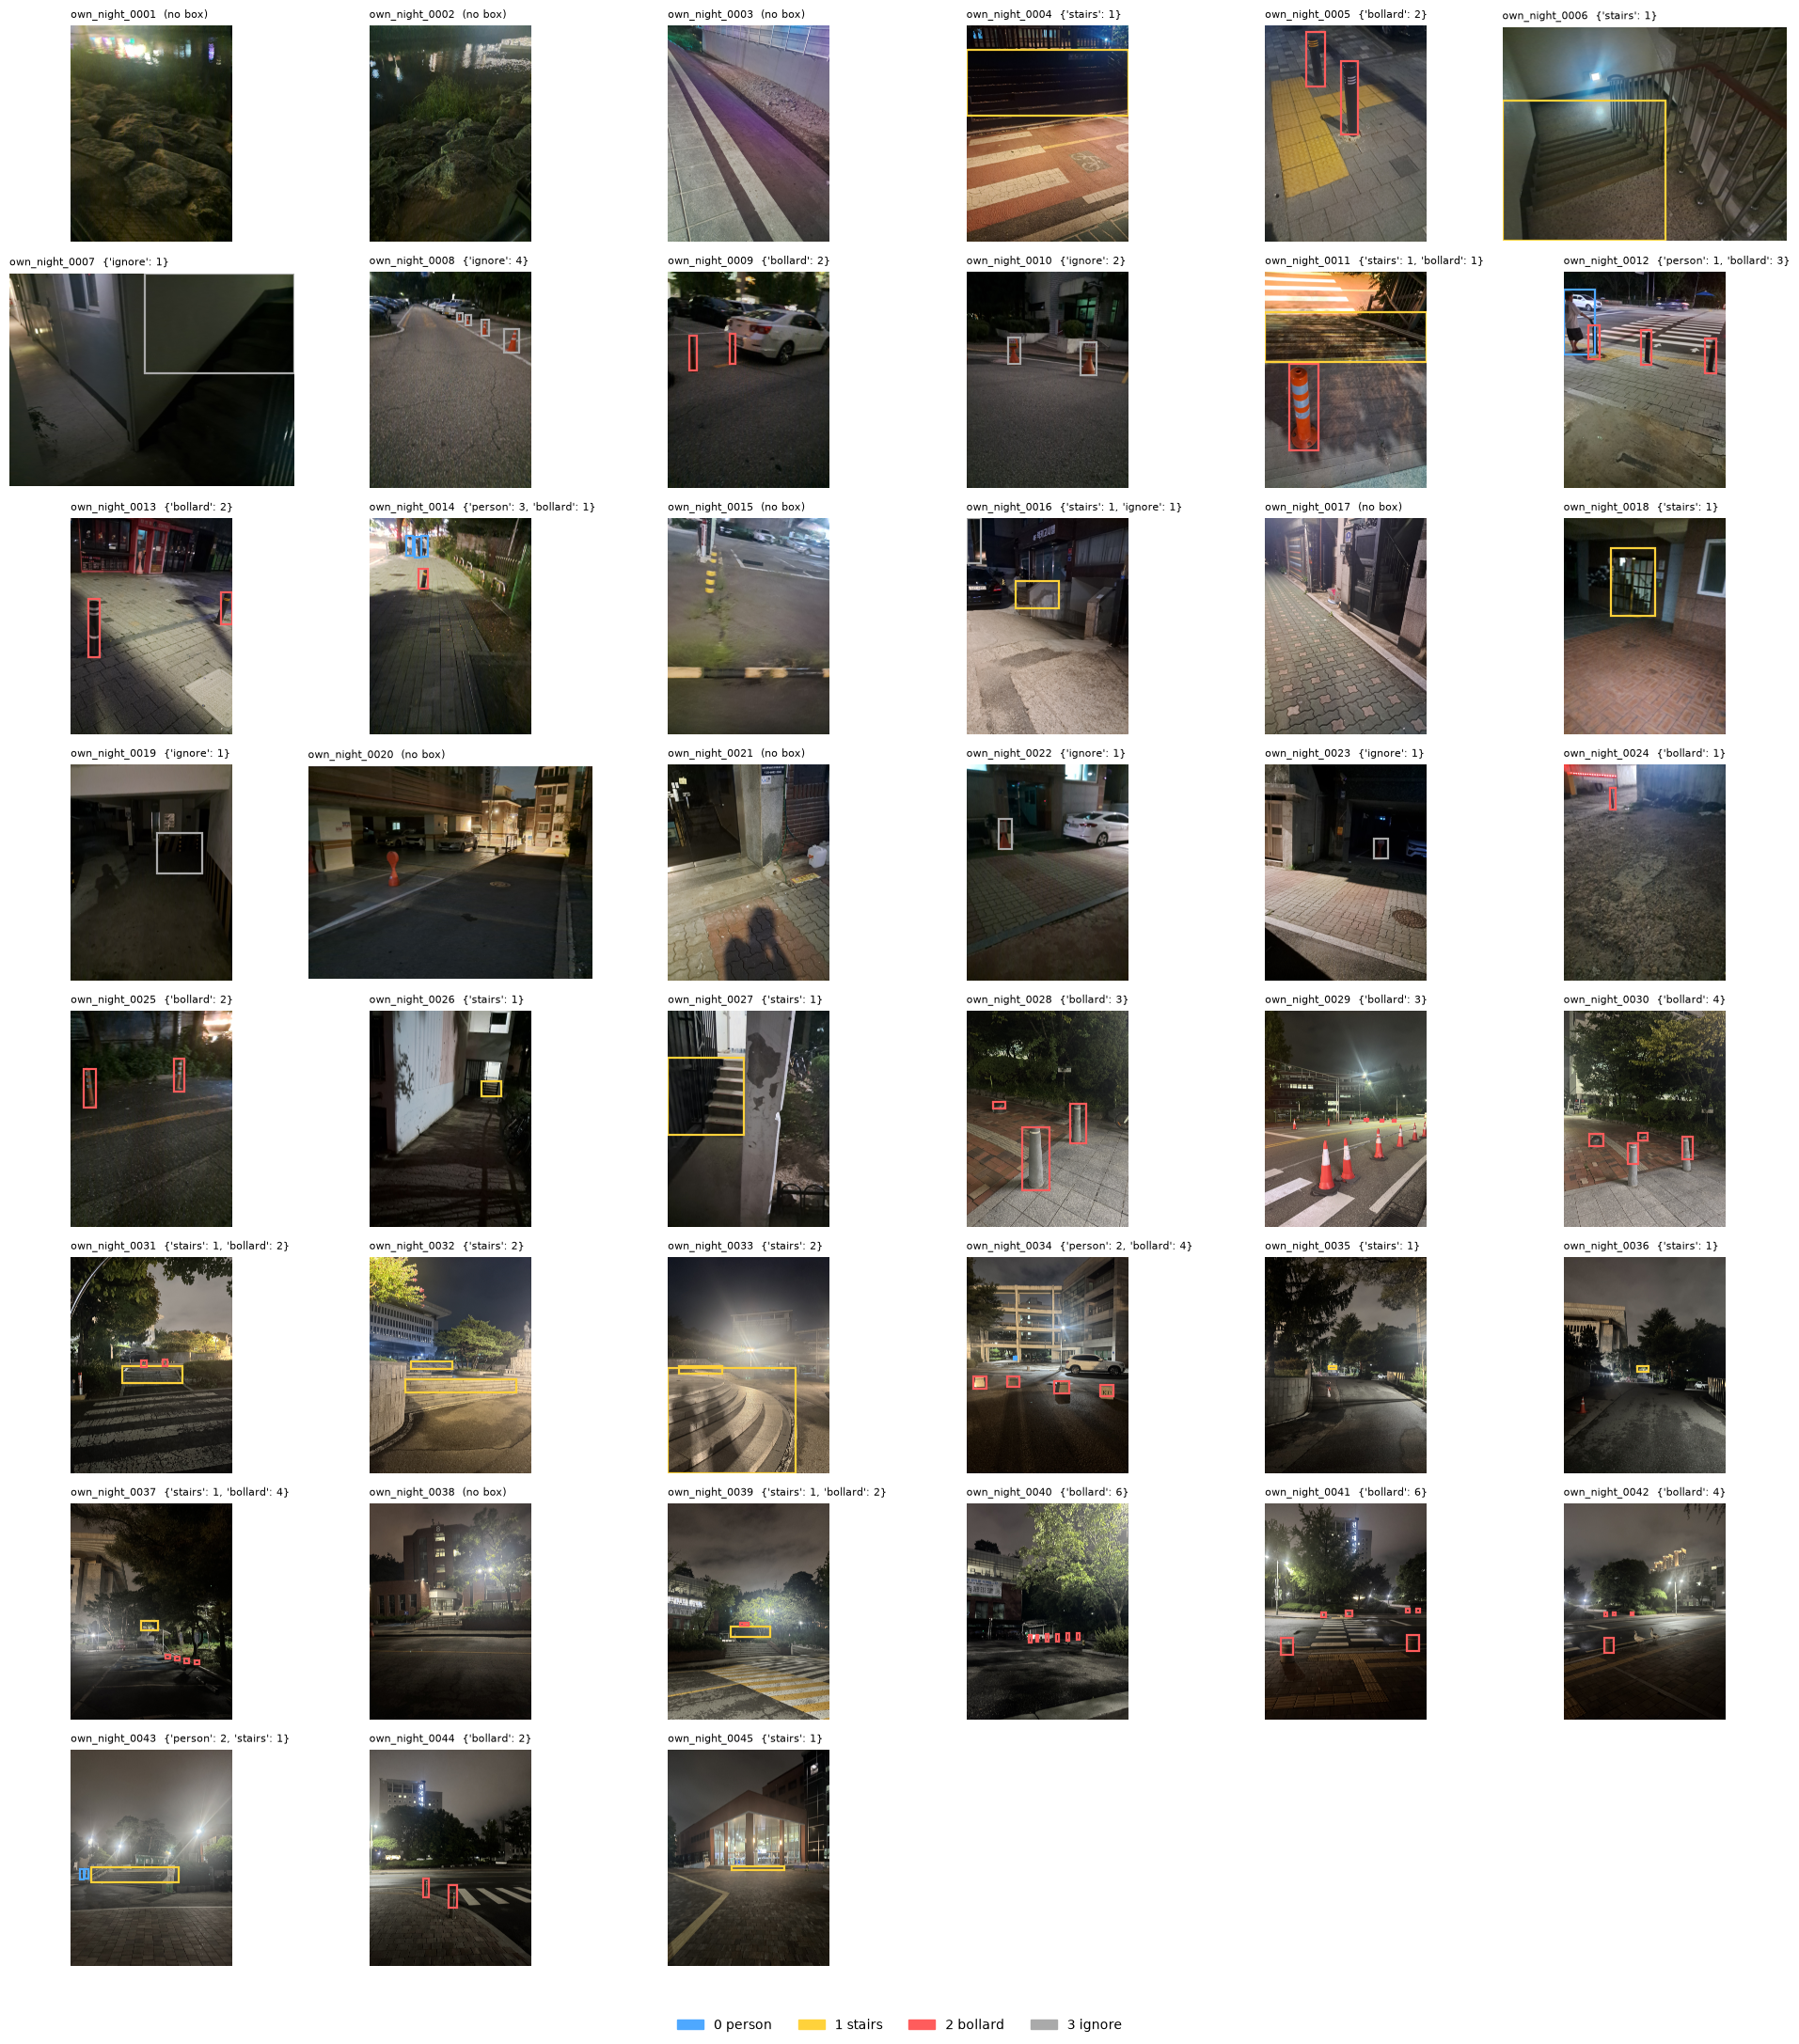

In [5]:
# 기존 27장 스팟체크 — negative 7장은 "(no box)"가 정상
LABELED = STATUS.loc[STATUS.status != "MISSING", "stem"].tolist()
show_grid(LABELED)

## 2. 수동 라벨링 — 좌표 직접 입력

`STEM`을 대상 파일명으로 바꾸고 아래 4개 셀을 순서대로: **보기(격자) → 입력 → 미리보기 → 저장**.
새 파일이면 빈 상태로, 기존 라벨이 있으면(수정 시) `existing_boxes_px`가 픽셀 좌표로 보여준다.

In [6]:
def show_pixel_grid(stem, step=400, figsize=(13, 8)):
    """기존 라벨 박스 + 픽셀 격자·눈금을 얹어 크게 그린다 (좌표를 눈으로 읽는 용도)."""
    img = load_image(stem)
    h, w = img.shape[:2]
    lab = load_labels(stem)
    fig, ax = plt.subplots(figsize=figsize)
    draw(ax, img, lab, title=f"{stem}  ({w}x{h})")
    ax.set_axis_on()
    ax.set_xticks(np.arange(0, w, step))
    ax.set_yticks(np.arange(0, h, step))
    ax.grid(True, color="white", alpha=0.4, linewidth=0.6)
    plt.show()


def existing_boxes_px(stem):
    """수정용 — 기존 라벨(정규화)을 픽셀 xyxy로 되짚는다."""
    h, w = load_image(stem).shape[:2]
    lab = load_labels(stem)
    return [(int(c), round((cx - bw / 2) * w), round((cy - bh / 2) * h),
             round((cx + bw / 2) * w), round((cy + bh / 2) * h)) for c, cx, cy, bw, bh in lab]


def px_to_norm(boxes_px, w, h):
    """[(cls, x1, y1, x2, y2), ...] 픽셀 → (N, 5) 정규화 cx,cy,w,h."""
    if not boxes_px:
        return np.zeros((0, 5))
    out = [[cls, (x1 + x2) / 2 / w, (y1 + y2) / 2 / h, (x2 - x1) / w, (y2 - y1) / h]
           for cls, x1, y1, x2, y2 in boxes_px]
    return np.array(out, dtype=float)


def save_labels(stem, boxes_px):
    """픽셀 xyxy → YOLO 정규화로 변환해 저장. 기존 파일은 _backup/ 으로 복사 후 덮어쓴다."""
    img = load_image(stem)
    h, w = img.shape[:2]
    norm = px_to_norm(boxes_px, w, h)
    path = LBL_DIR / f"{stem}.txt"
    if path.exists():
        BACKUP_DIR.mkdir(exist_ok=True)
        shutil.copy(path, BACKUP_DIR / f"{stem}.txt")
    lines = [f"{int(c)} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}" for c, cx, cy, bw, bh in norm]
    path.write_text("\n".join(lines) + ("\n" if lines else ""))
    print(f"저장: {path}  ({len(lines)}박스)")

In [7]:
# # ── 1) 보기 ── STEM을 바꿔가며 반복
# STEM = "own_night_0028"
# show_pixel_grid(STEM)
# print("기존 라벨(수정 시 참고):", existing_boxes_px(STEM))

In [8]:
# # ── 2) 입력 ── 위 그림 격자에서 좌표를 읽어 채운다. (class_id, x1, y1, x2, y2) 픽셀 xyxy
# # class_id: 0 person, 1 stairs, 2 bollard, 3 ignore
# boxes_px = [
#     (2, 500, 1000, 700, 1200),
#     (2, 1620, 3000, 2050, 4700),
#     (2, 1620, 3000, 2050, 4700),
# ]

# # ── 3) 미리보기 ── 저장 전 확인
# img = load_image(STEM)
# fig, ax = plt.subplots(figsize=(10, 6))
# draw(ax, img, px_to_norm(boxes_px, img.shape[1], img.shape[0]), title=f"{STEM} preview / (x, y): ({img.shape[1]}, {img.shape[0]})")
# plt.show()

In [9]:
# ── 4) 저장 ── 미리보기가 맞으면 실행
# save_labels(STEM, boxes_px)

### 남은 대상

위 4개 셀(보기 → 입력 → 미리보기 → 저장)을 `MISSING` 목록의 각 stem에 대해 반복한다.
라벨을 채운 뒤에는 맨 위 `1. 현재 라벨링 상태` 섹션을 다시 실행해 진행 상황을 확인한다.

In [10]:
# print(MISSING)

## 3. (더 쉬운 방법) cv2 창에서 마우스로 박스 입력

별도 창이 뜬다(노트북 인라인이 아니라 로컬 실행 시에만 동작). 이미지가 **모니터(1920x1080)를
넘지 않도록 자동 축소**해서 보여주며(비율 유지), 표시되는 좌표·저장되는 좌표는 항상 **원본
픽셀 기준**이다. **좌클릭 드래그**로 박스를 그리고 떼면 **숫자키 0/1/2/3**으로 클래스를
확정한다(회색 박스 = 기존 라벨 참고선). **우클릭**으로 확정 전 박스 취소, **u** = 마지막
확정 박스 취소, **q/ESC** = 종료(그때까지 확정된 박스를 반환하고 창이 닫힌다).

In [14]:
SCREEN_MAX = (1900, 1000)  # 1920x1080 모니터에 맞춘 표시 상한(여백 포함)


def _hex_to_bgr(hexcolor):
    r, g, b = (int(hexcolor.lstrip("#")[i:i + 2], 16) for i in (0, 2, 4))
    return (b, g, r)


def label_with_mouse(stem):
    """cv2 창에서 드래그로 박스를 그리고 숫자키로 클래스를 확정한다.
    화면에 맞게 이미지를 축소해 표시하지만, 표시/반환 좌표는 항상 원본 픽셀 기준이다.
    드래그(좌클릭 누른 채 이동 후 뗌) → 0/1/2/3 키로 클래스 확정해 담는다.
    우클릭=확정 전 박스 취소, u=마지막 확정 박스 취소, q/ESC=종료(그때까지 박스를 반환)."""
    img = load_image(stem)
    h, w = img.shape[:2]
    scale = min(SCREEN_MAX[0] / w, SCREEN_MAX[1] / h, 1.0)
    disp = cv2.resize(img, (round(w * scale), round(h * scale))) if scale < 1.0 else img
    base = cv2.cvtColor(disp, cv2.COLOR_RGB2BGR)
    for c, x1, y1, x2, y2 in existing_boxes_px(stem):
        cv2.rectangle(base, (round(x1 * scale), round(y1 * scale)),
                      (round(x2 * scale), round(y2 * scale)), (150, 150, 150), 1)

    boxes = []  # 원본 픽셀 좌표로 누적
    state = {"mouse": (0, 0), "drag_from": None, "pending": None}

    def redraw():
        frame = base.copy()
        for c, x1, y1, x2, y2 in boxes:
            color = _hex_to_bgr(CLASS_COLORS[c])
            p1 = (round(x1 * scale), round(y1 * scale))
            p2 = (round(x2 * scale), round(y2 * scale))
            cv2.rectangle(frame, p1, p2, color, 2)
            cv2.putText(frame, CLASS_NAMES[c], (p1[0], max(p1[1] - 4, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
        if state["drag_from"]:
            cv2.rectangle(frame, state["drag_from"], state["mouse"], (255, 255, 255), 1)
        if state["pending"]:
            x1, y1, x2, y2 = state["pending"]
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 255), 1)
            cv2.putText(frame, "class? 0/1/2/3", (x1, max(y1 - 6, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
        ox, oy = round(state["mouse"][0] / scale), round(state["mouse"][1] / scale)
        cv2.putText(frame, f"x={ox} y={oy}  (scale {scale:.2f})", (10, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 1)
        cv2.imshow(win, frame)

    def on_mouse(event, x, y, flags, _):
        state["mouse"] = (x, y)
        if event == cv2.EVENT_LBUTTONDOWN and state["pending"] is None:
            state["drag_from"] = (x, y)
        elif event == cv2.EVENT_LBUTTONUP and state["drag_from"]:
            x1, y1 = state["drag_from"]
            state["drag_from"] = None
            if x != x1 and y != y1:
                state["pending"] = (min(x1, x), min(y1, y), max(x1, x), max(y1, y))
        elif event == cv2.EVENT_RBUTTONDOWN:
            state["pending"] = None
            state["drag_from"] = None
        redraw()

    win = f"{stem}  drag=box  0/1/2/3=class  rclick/u=cancel  q/ESC=finish"
    cv2.namedWindow(win)
    cv2.setMouseCallback(win, on_mouse)
    redraw()
    while True:
        key = cv2.waitKey(20) & 0xFF
        if key in (27, ord("q")):
            break
        elif key == ord("u") and boxes:
            boxes.pop()
            redraw()
        elif state["pending"] and chr(key) in "0123":
            x1, y1, x2, y2 = state["pending"]
            boxes.append((int(chr(key)), round(x1 / scale), round(y1 / scale),
                          round(x2 / scale), round(y2 / scale)))
            state["pending"] = None
            redraw()
    cv2.destroyWindow(win)
    return boxes

In [158]:
STEM = "own_night_0045"
boxes_px = label_with_mouse(STEM)
print(boxes_px)

[(1, 1000, 3050, 3284, 3204)]


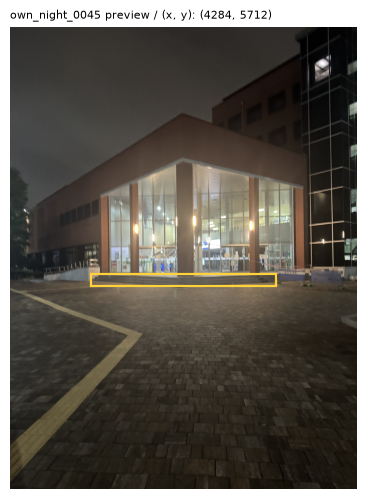

In [159]:
# class_id: 0 person, 1 stairs, 2 bollard, 3 ignore
# ── 미리보기 ── 저장 전 확인
img = load_image(STEM)
fig, ax = plt.subplots(figsize=(10, 6))
draw(ax, img, px_to_norm(boxes_px, img.shape[1], img.shape[0]), title=f"{STEM} preview / (x, y): ({img.shape[1]}, {img.shape[0]})")
plt.show()

In [160]:
# ── 4) 저장 ── 미리보기가 맞으면 실행
save_labels(STEM, boxes_px)

저장: c:\Users\USER\Documents\KDT_Hackathon\data\own_night\labels\own_night_0045.txt  (1박스)


저장은 위 2절의 `save_labels(STEM, boxes_px)` 셀을 그대로 다시 실행한다(코드 중복 없음).